CHAP 3 QUESTION 8

In [1]:
#Our model is mpg=β0 +β1 horsepower+ϵ

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Read the Auto dataset
Auto = pd.read_csv("Auto.csv")

# Display the first five rows
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [2]:
Auto.columns
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
Auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB


In [4]:
#Here horseower is shown as object let me convert it 
Auto["horsepower"] = pd.to_numeric(
    Auto["horsepower"],
    errors="coerce"
)

In [5]:
#remove missing values
Auto = Auto.dropna(subset=["mpg", "horsepower"])

In [6]:
#The predictor is: X=horsepower
#The response is: Y=mpg
X = Auto["horsepower"]
y = Auto["mpg"]

# Add intercept
X = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Display regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Wed, 19 Aug 2026   Prob (F-statistic):           7.03e-81
Time:                        09:54:23   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

In [ ]:
#(a)(i) Is there a relationship between horsepower and mpg?

#Look at the p-value for horsepower. It should be extremely small: p<0.001 Therefore, we reject the null hypothesis:
# H0:β1=0  There is strong statistical evidence of a relationship between horsepower and MPG.
#Answer: Yes. There is a statistically significant relationship between horsepower and mpg because the p-value for horsepower is much smaller than 0.05.

In [ ]:
#(a)(ii) How strong is the relationship?
#Look at:R2  For this regression:R2 ≈0.606
#This means approximately 60.6% of the variation in mpg is explained by horsepower.

#Answer: The relationship is fairly strong. The R-squared value is approximately 0.606, meaning that horsepower explains about 60.6% of the variation in mpg.

In [ ]:
#(a)(iii) Is the relationship positive or negative?
#Look at the coefficient of horsepower. It is approximately:β^1=−0.158
#The coefficient is negative.=>There is a negative relationship between horsepower and mpg. As horsepower increases, mpg tends to decrease.
# To mean For every additional 1 horsepower, predicted mpg decreases by about 0.158 mpg, on average.

In [7]:
#(a)(iv) Prediction when horsepower = 98
# Create a new observation with horsepower = 98
new_data = pd.DataFrame({
    "const": [1],
    "horsepower": [98]
})

# Prediction and confidence/prediction intervals
prediction = model.get_prediction(new_data)

prediction_summary = prediction.summary_frame(alpha=0.05)

print(prediction_summary)

        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  24.467077  0.251262      23.973079      24.961075     14.809396   

   obs_ci_upper  
0     34.124758  


The confidence interval estimates the uncertainty around the mean mpg for cars with 98 horsepower.

The prediction interval estimates the uncertainty for the mpg of one individual car with 98 horsepower.

Therefore, the prediction interval is much wider.

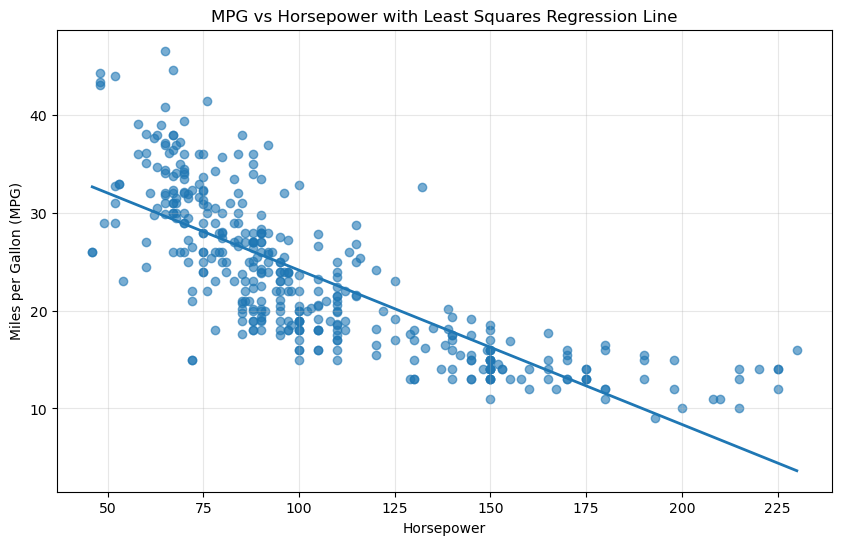

In [8]:
#(b) SCATTERPLOT + REGRESSION LINE
# Create a new figure
fig, ax = plt.subplots(figsize=(10, 6))

# Scatterplot
ax.scatter(
    Auto["horsepower"],
    Auto["mpg"],
    alpha=0.6
)

# Regression line
x_values = np.linspace(
    Auto["horsepower"].min(),
    Auto["horsepower"].max(),
    100
)

X_line = sm.add_constant(x_values)

y_values = model.predict(X_line)

ax.plot(
    x_values,
    y_values,
    linewidth=2
)

# Labels
ax.set_xlabel("Horsepower")
ax.set_ylabel("Miles per Gallon (MPG)")
ax.set_title("MPG vs Horsepower with Least Squares Regression Line")

ax.grid(alpha=0.3)

plt.show()

Expectation: The plot should show a downward-sloping regression line.

This visually confirms the negative relationship:

horsepower↑⇒mpg↓

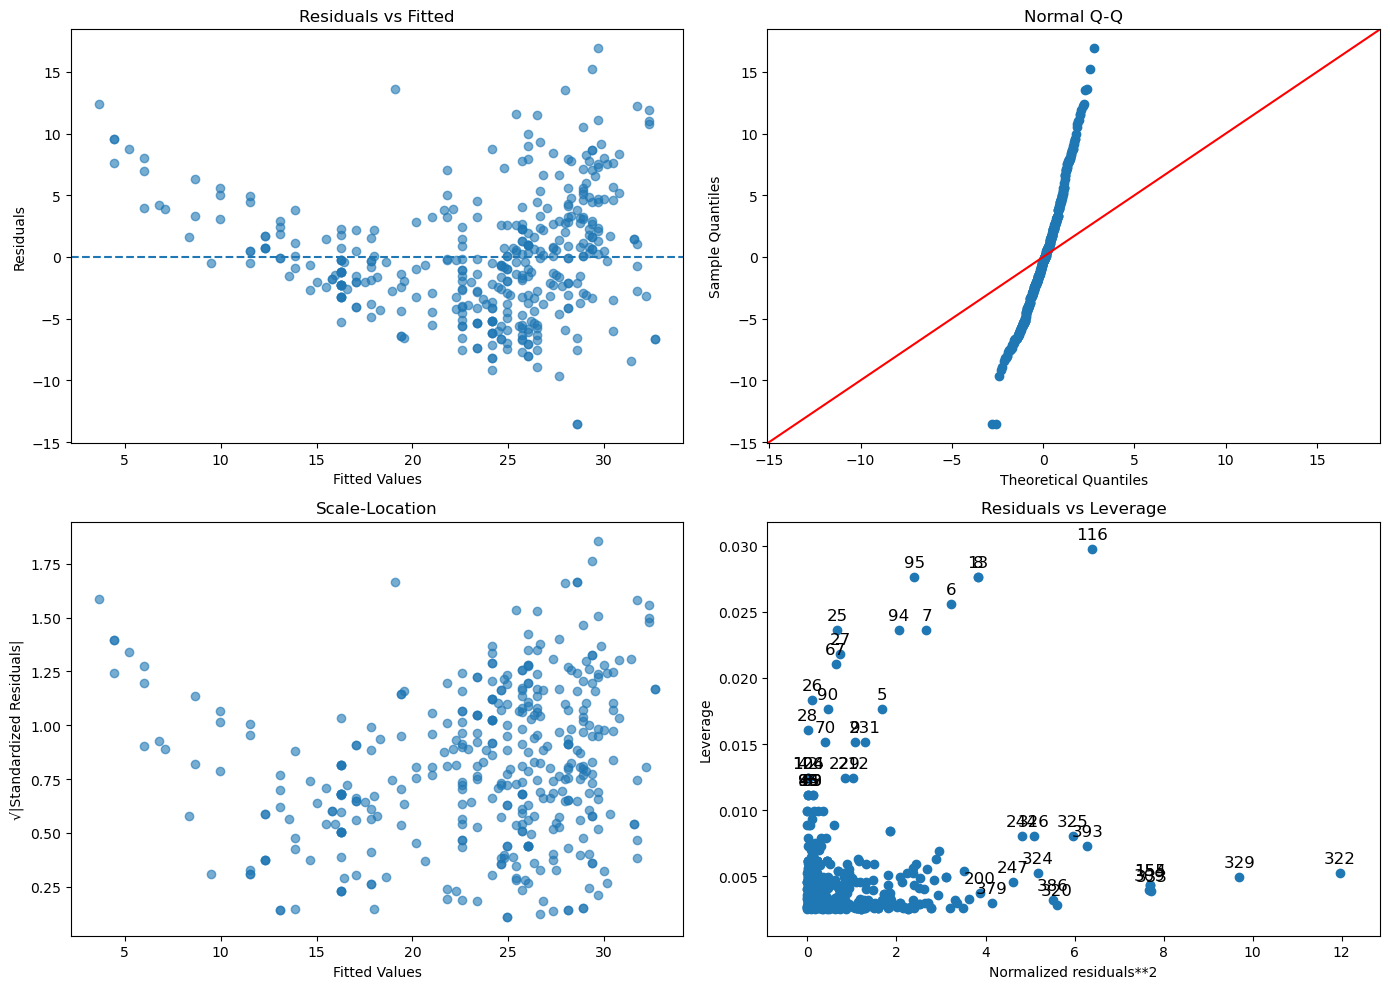

In [9]:
#(c) Diagnostic plots
#Now we check whether there are problems with our linear regression model.
#We will examine:
#Residuals vs fitted values
#Normal Q-Q plot
#Scale-location plot
#Residuals vs leverage

import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---------------------------------------------------------
# 1. Residuals vs Fitted
# ---------------------------------------------------------

axes[0, 0].scatter(
    model.fittedvalues,
    model.resid,
    alpha=0.6
)

axes[0, 0].axhline(
    0,
    linestyle="--"
)

axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")


# ---------------------------------------------------------
# 2. Normal Q-Q
# ---------------------------------------------------------

sm.qqplot(
    model.resid,
    line="45",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Normal Q-Q")


# ---------------------------------------------------------
# 3. Scale-Location
# ---------------------------------------------------------

standardized_residuals = (
    model.resid / np.sqrt(model.mse_resid)
)

axes[1, 0].scatter(
    model.fittedvalues,
    np.sqrt(np.abs(standardized_residuals)),
    alpha=0.6
)

axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("√|Standardized Residuals|")
axes[1, 0].set_title("Scale-Location")


# ---------------------------------------------------------
# 4. Residuals vs Leverage
# ---------------------------------------------------------

from statsmodels.graphics.regressionplots import plot_leverage_resid2

plot_leverage_resid2(
    model,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Residuals vs Leverage")

plt.tight_layout()
plt.show()

OVERALL CONCLUSION
The diagnostic plots indicate that the simple linear regression model is not a perfect fit for the Auto data.
The residuals versus fitted values plot shows some curvature, suggesting that the relationship between horsepower and mpg may not be completely linear.
The Q-Q plot shows some deviations from the straight line, particularly in the tails, suggesting that the residuals are not perfectly normally distributed. 
There may also be some evidence of non-constant variance and a few observations that could have relatively high leverage.
Therefore, although horsepower is a strong and statistically significant predictor of mpg, a simple linear regression may not capture the entire relationship between the two variables.